<a href="https://colab.research.google.com/github/whyeon92/ESAA_OB/blob/Code_Study/ESAA_HW1111.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#텐서플로가 업데이트 이후 버전간의 충돌이 많기에 버전 확인함
print(tf.__version__)

2.17.0


In [ ]:
!pip uninstall tensorflow

Found existing installation: tensorflow 2.17.0
Uninstalling tensorflow-2.17.0:
  Would remove:
    /usr/local/bin/import_pb_to_tensorboard
    /usr/local/bin/saved_model_cli
    /usr/local/bin/tensorboard
    /usr/local/bin/tf_upgrade_v2
    /usr/local/bin/tflite_convert
    /usr/local/bin/toco
    /usr/local/bin/toco_from_protos
    /usr/local/lib/python3.10/dist-packages/tensorflow-2.17.0.dist-info/*
    /usr/local/lib/python3.10/dist-packages/tensorflow/*
Proceed (Y/n)? Y
  Successfully uninstalled tensorflow-2.17.0


In [ ]:
!pip install tensorflow==2.15

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: tensorboard
    Found existing installation:

# 1. 딥러닝 준비

In [ ]:
import tensorflow as tf

#클래스
tf.keras.losses.BinaryCrossentropy()

#함수
tf.keras.losses.binary_crossentropy

<function keras.src.losses.binary_crossentropy(y_true, y_pred, from_logits=False, label_smoothing=0.0, axis=-1)>

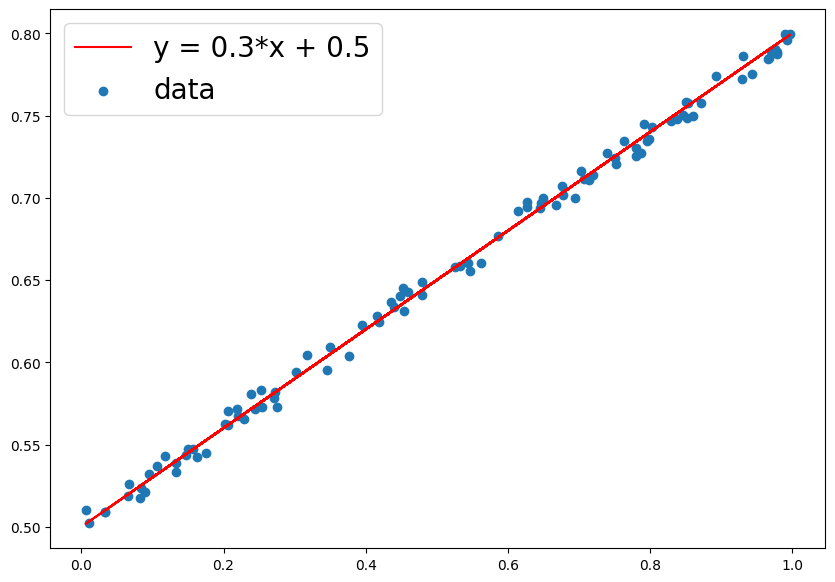

w:0.3, b:0.5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#샘플에 활용할 데이터셋 만들기
def make_linear(w = 0.5, b = 0.8, size = 50, noise = 1.0):
    x = np.random.rand(size)
    y = w*x + b
    noise = np.random.uniform(-abs(noise), abs(noise), size = y.shape)
    yy = y + noise
    plt.figure(figsize = (10, 7))
    plt.plot(x, y, color = 'r', label = f'y = {w}*x + {b}')
    plt.scatter(x, yy, label = 'data')
    plt.legend(fontsize = 20)
    plt.show()
    print(f'w:{w}, b:{b}')
    return x, yy

x, y = make_linear(w = 0.3, b = 0.5, size = 100, noise = 0.01)

In [ ]:
#최대 반복 횟수
num_epoch = 1000

#학습률(learning_rate)
learning_rate = 0.005

#에러 기록
errors = []

#random한 값으로 w, b를 초기화
w = np.random.uniform(low = 0.0, high = 1.0)
b = np.random.uniform(low = 0.0, high = 1.0)

for epoch in range(num_epoch):
    #Hypothesis 정의
    y_hat = w*x + b

    #Loss Function 정의
    error = 0.5*((y_hat - y)**2).sum()
    if error < 0.005:
        break
    #Gradient 미분 계산
    w = w - learning_rate*((y_hat - y)*x).sum()
    b = b - learning_rate*(y_hat - y).sum()

    errors.append(error)

    if epoch % 5 == 0:
        print("{0:2} w = {1:.5f}, b = {2:.5f} error = {3:.5f}".format(epoch, w, b, error))

print("----"*15)
print("{0:2} w = {1:.1f}, b = {2:.1f} error = {3:.5f}".format(epoch, w, b, error))

 0 w = 0.08924, b = 0.69515 error = 2.64305
 5 w = 0.09640, b = 0.61412 error = 0.20459
10 w = 0.12957, b = 0.59510 error = 0.14260
15 w = 0.15738, b = 0.57952 error = 0.09955
20 w = 0.18057, b = 0.56652 error = 0.06962
25 w = 0.19991, b = 0.55569 error = 0.04881
30 w = 0.21603, b = 0.54666 error = 0.03435
35 w = 0.22947, b = 0.53912 error = 0.02429
40 w = 0.24068, b = 0.53284 error = 0.01730
45 w = 0.25002, b = 0.52761 error = 0.01243
50 w = 0.25782, b = 0.52324 error = 0.00905
55 w = 0.26431, b = 0.51960 error = 0.00670
60 w = 0.26973, b = 0.51656 error = 0.00507
------------------------------------------------------------
61 w = 0.3, b = 0.5 error = 0.00481


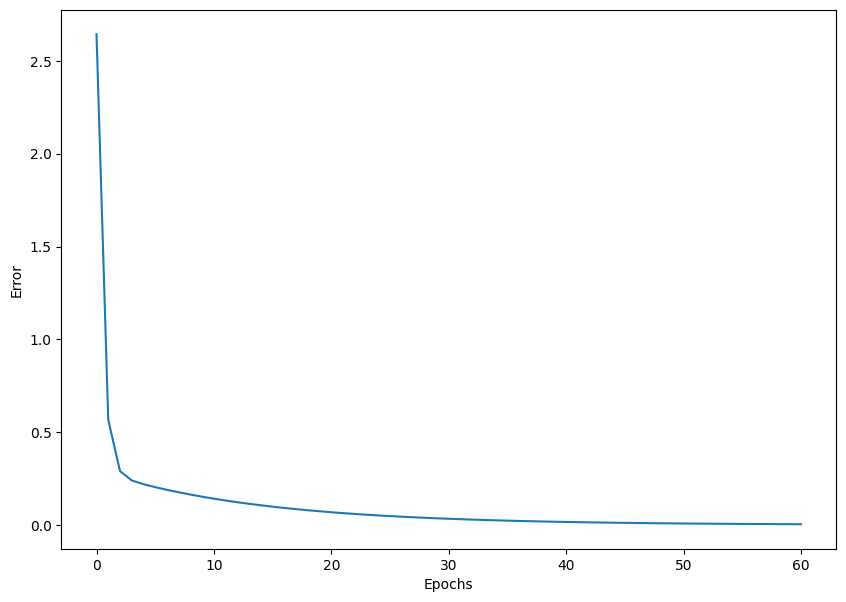

In [ ]:
plt.figure(figsize = (10, 7))
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

# 2. 단순 신경망 훈련

In [ ]:
import tensorflow as tf

# 10개의 노드로 이루어진 Dense 레이어
tf.keras.layers.Dense(10)

#ReLU 활성화 함수 적용
tf.keras.layers.Dense(10, activation = 'relu')

In [ ]:
# 샘플 데이터셋 생성
x = np.arange(1, 6)

# y = 3x + 2
y = 3*x + 2
print(x)
print(y)

[1 2 3 4 5]
[ 5  8 11 14 17]


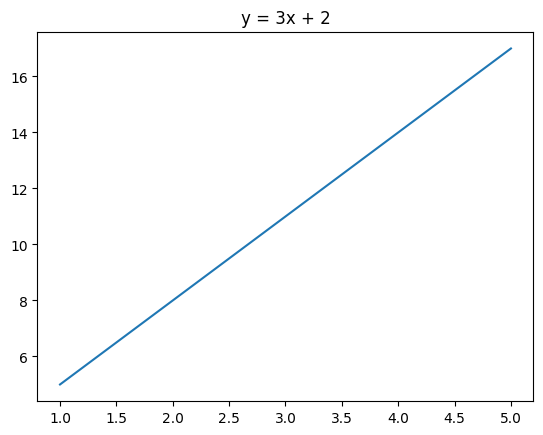

In [ ]:
import matplotlib.pyplot as plt

#시각화
plt.plot(x, y)
plt.title('y = 3x + 2')
plt.show()

In [ ]:
import tensorflow as tf

#리스트형
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1)
])

In [ ]:
#add 함수로 레이어 추가
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(10))
model.add(tf.keras.layers.Dense(5))
model.add(tf.keras.layers.Dense(1))

In [ ]:
import tensorflow as tf
model = tf.keras.Sequential([
    #입력 데이터의 shape = (150, 4)인 경우 input_shape 지정
    tf.keras.layers.Dense(10, input_shape = [4]),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1)
])

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape = [1])
])

In [ ]:
#모델 요약
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 1)                 2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
#긴 문자열 지정
model.compile(optimizer = 'sgd', loss = 'mean_squared_error',
              metrics = ['mean_squared_error', 'mean_absolute_error'])

In [ ]:
#짧은 문자열 지정
model.compile(optimizer = 'sgd', loss = 'mse', metrics = ['mse', 'mae'])

In [ ]:
#클래스 인스턴스 지정
model.compile(optimizer = tf.keras.optimizers.SGD(lr = 0.005),
              loss = tf.keras.losses.MeanAbsoluteError(),
              metrics = [tf.keras.losses.MeanAbsoluteError(),
                         tf.keras.losses.MeanSquaredError()])

In [ ]:
# 컴파일
model.compile(optimizer = 'sgd', loss = 'mse', metrics = ['mae'])

In [ ]:
#훈련
model.fit(x, y, epochs = 5)

Epoch 1/5
1/1 [==============================] - 0s 337ms/step - loss: 13.1849 - mae: 3.4678
Epoch 2/5
1/1 [==============================] - 0s 10ms/step - loss: 7.7445 - mae: 2.6829
Epoch 3/5
1/1 [==============================] - 0s 12ms/step - loss: 4.5737 - mae: 2.0836
Epoch 4/5
1/1 [==============================] - 0s 9ms/step - loss: 2.7256 - mae: 1.6260
Epoch 5/5
1/1 [==============================] - 0s 10ms/step - loss: 1.6481 - mae: 1.2765


In [ ]:
# 단순 선형회귀 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape = [1])
])

# 컴파일
model.compile(optimizer = 'sgd', loss = 'mse', metrics = ['mae'])

#훈련
history = model.fit(x, y, epochs = 1200)

Epoch 1/1200
1/1 [==============================] - 0s 322ms/step - loss: 118.1117 - mae: 10.1637
Epoch 2/1200
1/1 [==============================] - 0s 11ms/step - loss: 68.9297 - mae: 7.8044
Epoch 3/1200
1/1 [==============================] - 0s 9ms/step - loss: 40.2683 - mae: 6.0032
Epoch 4/1200
1/1 [==============================] - 0s 9ms/step - loss: 23.5651 - mae: 4.6281
Epoch 5/1200
1/1 [==============================] - 0s 13ms/step - loss: 13.8307 - mae: 3.5782
Epoch 6/1200
1/1 [==============================] - 0s 10ms/step - loss: 8.1573 - mae: 2.7765
Epoch 7/1200
1/1 [==============================] - 0s 9ms/step - loss: 4.8504 - mae: 2.1644
Epoch 8/1200
1/1 [==============================] - 0s 9ms/step - loss: 2.9227 - mae: 1.6970
Epoch 9/1200
1/1 [==============================] - 0s 13ms/step - loss: 1.7987 - mae: 1.3400
Epoch 10/1200
1/1 [==============================] - 0s 10ms/step - loss: 1.1430 - mae: 1.0674
Epoch 11/1200
1/1 [==============================] - 0s

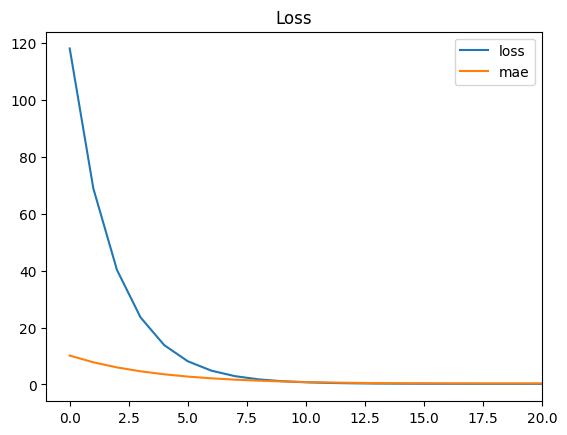

In [ ]:
import matplotlib.pyplot as plt

#20epoch까지 Loss 수렴에 대한 시각화
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['mae'], label = 'mae')
plt.xlim(-1, 20)
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
# 검증
model.evaluate(x, y)

1/1 [==============================] - 0s 143ms/step - loss: 7.1978e-05 - mae: 0.0073


[7.19778036000207e-05, 0.007282161619514227]

In [ ]:
# 예측
model.predict([10])

1/1 [==============================] - 0s 136ms/step


array([[32.035194]], dtype=float32)

1. 선형회귀  
 : 하나 이상의 독립변수(X)들이 종속변수(y)에 미치는 영향을 추정하는 통계 기법  
 딥러닝에서의 단순선형회귀→ 모델의 가중치 w와 편향 b를 업데이트  
 → 가장 y에 근사한 1차 함수식 탐색   
2. 뉴런  
 : 인공 신경망 모델을 구성하는 하나의 신경 = 노드
3. Dense Layer  
 : 각 레이어와 레이어 사이에 모든 뉴런이 서로 연결된 완전 연결층, 심층 신경망을 구성하는 가장 기본 레이어  
 `tf.keras.layers.Dense`로 구현 가능
4. 데이터셋 만들기  
 : 딥러닝으로 단순선형회귀를 구현하기 위해 만드는 데이터, `numpy`의 `arange` 사용  
5. Sequential API  
 : 딥러닝 모델을 만들 때 층을 쌓도록 만들어주는 API  
 - `tf.keras.Sequential([layer1, layer2, ...])`
 - `model = tf.keras.Sequential()`
  `model.add(layer1)`

6. 모델 요약  
 `model.summary` 메소드로 모델이 계산해야할 파라미터 수 파악 가능
7. Compile  
 : 모델의 optimizer, loss, metric을 지정  
 클래스 인스턴스로 해당 값들을 지정하면 하이퍼 파라미터 등도 사용자가 조절 가능  
 ex) Adam Optimizer 사용 시 클래스 인스턴스로 하면 lr가 지정 가능!  
 =문자열 형식으로 지정하면 이런 하이퍼 파라미터들이 모두 기본값으로 지정됨  
8. 훈련  
 `fit(X_train, y_train, epochs)` 메소드를 모델에 적용, 모델 훈련.  
 훈련은 loss가 점차 줄어드는 방향으로 진행
9. 검증  
 `model.evaluate(x_val, y_val)`  
 검증 데이터에 대한 loss, metric 값을 반환  
10. 예측  
 `model.predict(X_test)`  
 변수들을 입력받아 예측값 반환  

# 3. 심층 신경망으로 이미지 분류

In [ ]:
import tensorflow as tf

#케라스의 내장 데이터셋에서 mnist 데이터셋 로드
mnist = tf.keras.datasets.mnist

In [ ]:
# load_data()로 데이터셋 로드
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [ ]:
# 로드된 데이터셋 확인
print('train set:', x_train.shape, y_train.shape)
print('test set:', x_test.shape, y_test.shape)

train set: (60000, 28, 28) (60000,)
test set: (10000, 28, 28) (10000,)


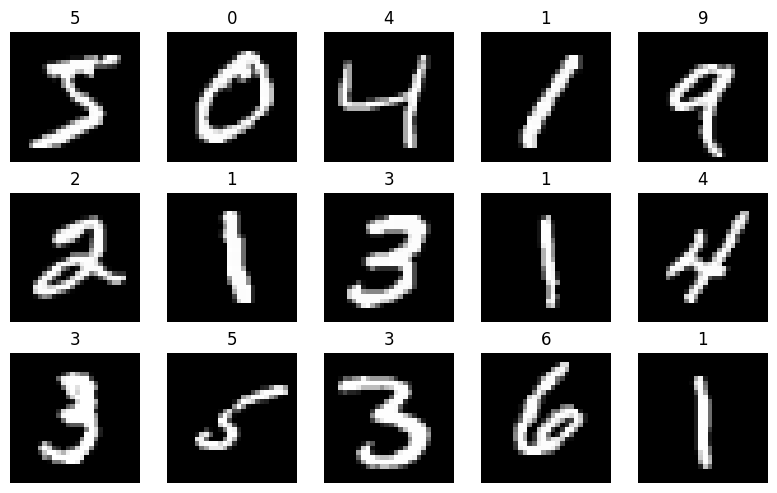

In [ ]:
#데이터 시각화
import matplotlib.pyplot as plt

#canvas 생성
fig, axes = plt.subplots(3, 5)
fig.set_size_inches(8, 5)

for i in range(15):
    ax = axes[i//5, i%5]
    #imshow로 이미지 시각화
    ax.imshow(x_train[i], cmap = 'gray')
    ax.axis('off')
    ax.set_title(str(y_train[i]))

plt.tight_layout()
plt.show()

In [ ]:
#x_train 배열의 데이터 확인
x_train[0, 10:15, 10:15]

array([[  1, 154, 253,  90,   0],
       [  0, 139, 253, 190,   2],
       [  0,  11, 190, 253,  70],
       [  0,   0,  35, 241, 225],
       [  0,   0,   0,  81, 240]], dtype=uint8)

In [ ]:
# 픽셀 값의 최소/최대값 확인
print(f'정규화 전] 최소값: {x_train.min()}, 최대값: {x_train.max()}')

#데이터 정규화
x_train = x_train/x_train.max()

#정규화 후 최소/최대값 확인
print(f'정규화 후] 최소값: {x_train.min()}, 최대값: {x_train.max()}')

정규화 전] 최소값: 0, 최대값: 255
정규화 후] 최소값: 0.0, 최대값: 1.0


In [ ]:
#test 셋에도 정규화 동일 적용
x_test = x_test / x_test.max()

In [ ]:
# 변환 후 x_train 배열의 데이터 확인
x_train[0, 10:15, 10:15]

array([[0.00392157, 0.60392157, 0.99215686, 0.35294118, 0.        ],
       [0.        , 0.54509804, 0.99215686, 0.74509804, 0.00784314],
       [0.        , 0.04313725, 0.74509804, 0.99215686, 0.2745098 ],
       [0.        , 0.        , 0.1372549 , 0.94509804, 0.88235294],
       [0.        , 0.        , 0.        , 0.31764706, 0.94117647]])

In [ ]:
print(f"변경 전 shape: {x_train.shape}")
print(f"1D으로 shape 변경 후: {x_train.reshape(60000, -1).shape}")

변경 전 shape: (60000, 28, 28)
1D으로 shape 변경 후: (60000, 784)


In [ ]:
print(f"변경 전 shape: {x_train.shape}")

#Flatten 레이어 적용 후 shape 확인
print(f"Flatten 적용 후: {tf.keras.layers.Flatten()(x_train).shape}")

변경 전 shape: (60000, 28, 28)
Flatten 적용 후: (60000, 784)


In [ ]:
# Dense 레이어에 relu 활성화 함수를 적용한 경우
tf.keras.layers.Dense(128, activation = 'relu')

In [ ]:
# Dense 레이어와 relu 활성화 함수 레이어를 별도 적용한 경우
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128),
    tf.keras.layers.Activation('relu')
])

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28, 28)),
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(32, activation = 'relu'),
    #노드 = 10개 (클래스 개수와 동일)
    tf.keras.layers.Dense(10, activation = 'softmax')
])

In [ ]:
# 출력층 노드 = 1인 경우, sigmoid
tf.keras.layers.Dense(1, activation = 'sigmoid')

# 출력층 노드 = 2개 이상인 경우, softmax
tf.keras.layers.Dense(10, activation = 'softmax')

In [ ]:
#이진분류(출력 노드 개수 = 1, sigmoid인 경우)
model.compile(loss = 'binary_crossentropy')

In [ ]:
#y가 원핫 벡터인 경우
#[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]
model.compile(loss = 'categorical_crossentropy')
#y가 원핫 벡터가 아닌 경우
#[5]
model.compile(loss = 'sparse_categorical_crossentropy')

In [ ]:
#클래스 인스턴스로 지정
adam = tf.keras.optimizers.Adam(lr = 0.001)
model.compile(optimizer = adam)

#문자열로 지정
model.compile(optimizer = 'adam')

In [ ]:
#클래스 인스턴스로 지정
acc = tf.keras.metrics.SparseCategoricalAccuracy()

model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = [acc])

In [ ]:
#문자열로 지정
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [ ]:
#훈련
model.fit(x_train, y_train,
          #검증 셋 지정
          validation_data = (x_test, y_test),
          epochs = 10
          )

Epoch 1/10
1875/1875 [==============================] - 13s 7ms/step - loss: 0.2371 - accuracy: 0.9306 - val_loss: 0.1238 - val_accuracy: 0.9611
Epoch 2/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0966 - accuracy: 0.9708 - val_loss: 0.0939 - val_accuracy: 0.9698
Epoch 3/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0673 - accuracy: 0.9791 - val_loss: 0.0881 - val_accuracy: 0.9739
Epoch 4/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0515 - accuracy: 0.9835 - val_loss: 0.0860 - val_accuracy: 0.9733
Epoch 5/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0410 - accuracy: 0.9866 - val_loss: 0.0830 - val_accuracy: 0.9759
Epoch 6/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0340 - accuracy: 0.9890 - val_loss: 0.0800 - val_accuracy: 0.9790
Epoch 7/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0289 - accuracy: 0.9906 - val_loss: 0.0848 - val_ac

In [ ]:
# 검증
test_loss, test_acc = model.evaluate(x_test, y_test)

print('검증 셋 정확도:', test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.0863 - accuracy: 0.9800
검증 셋 정확도: 0.9800000190734863


In [ ]:
# 예측
predictions = model.predict(x_test)

313/313 [==============================] - 1s 2ms/step


In [ ]:
#예측 결과 출력
predictions[0]

array([1.9349936e-12, 2.8110572e-09, 1.1314163e-07, 1.1505078e-07,
       6.0803529e-08, 5.2049433e-14, 7.0373403e-12, 9.9999970e-01,
       2.5206128e-13, 4.0925223e-09], dtype=float32)

In [ ]:
import numpy as np

#0번 index에 대한 예측 클래스 출력
print(np.argmax(predictions[0]))

#첫 10개 index에 대한 예측 클래스 출력
print(np.argmax(predictions[:10], axis = 1))

7
[7 2 1 0 4 1 4 9 5 9]


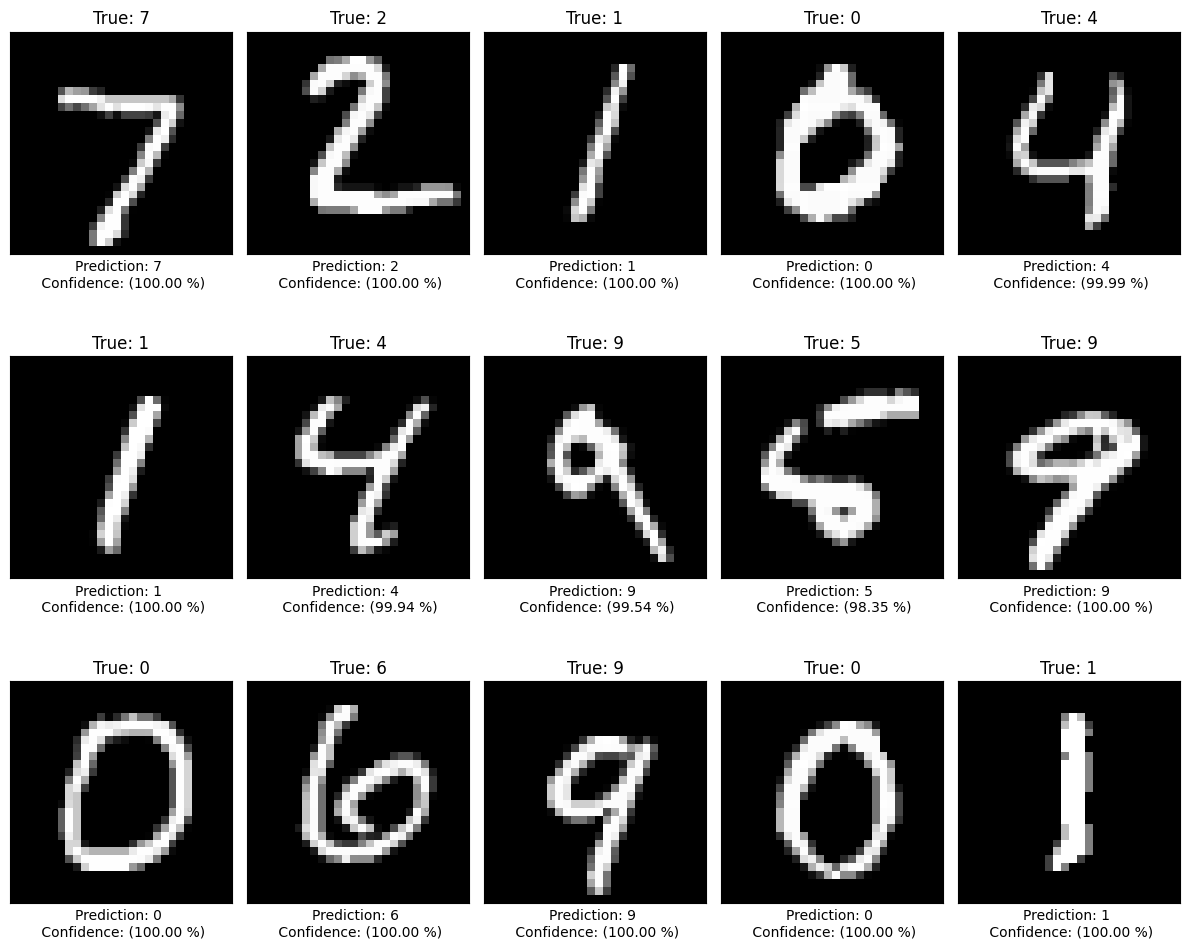

In [ ]:
# 데이터 시각화
import matplotlib.pyplot as plt
def get_one_result(idx):
    img, y_true, y_pred, confidence = x_test[idx], y_test[idx], np.argmax(predictions[idx]), 100*np.max(predictions[idx])
    return img, y_true, y_pred, confidence

#canvas 생성
fig, axes = plt.subplots(3, 5)
fig.set_size_inches(12, 10)
for i in range(15):
    ax = axes[i//5, i%5]
    img, y_true, y_pred, confidence = get_one_result(i)
    #imshow로 이미지 시각화
    ax.imshow(img, cmap = 'gray')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'True: {y_true}')
    ax.set_xlabel(f'Prediction: {y_pred} \n Confidence: ({confidence:.2f} %)')
plt.tight_layout()
plt.show()